# Aidos：一种面向非地球同步轨道巨型星座波束跳变调度的混合优化算法

## 摘要

随着非地球静止轨道（NGSO）巨型星座的快速发展，波束跳变（BH）已成为多卫星、多重覆盖场景下资源调度不可或缺的技术。通过在每个时隙内动态调整点波束的功率与指向，BH 能够实现高效的频谱利用。其中，一项主要的工程挑战是实时生成波束跳变时间计划（BHTP）。

传统算法（如轮询策略）以轮询方式将波束均匀分配至所有服务小区。然而，实际业务流量呈长尾分布：最活跃的 10% 热点小区产生了超过 50% 的总需求，因此均匀分配难以满足需求。为解决这一问题，现有框架采用遗传算法（GA），其吞吐量较传统基线提高约 80.7%。实际运行的卫星覆盖范围包含超过 1,000 个服务小区，而 GA 为 1,127 个小区生成一份 BHTP 需要 67.8 秒。对于轨道高度为 550 千米、可见时间窗口仅为 300 秒的低地球轨道（LEO）卫星，多次在线重新计算并不现实。多智能体深度强化学习（MADRL）等先进算法在小区数量超过 200 个时便无法收敛。

为克服这些挑战，我们提出了一种新的 BH 调度算法 Aidos。该算法将业务流量感知的随机键编码融入多目标元启发式搜索，并在自适应分布演化过程中采用滑动窗口 Beta 重采样策略，以同时提高 BHTP 的搜索效率与解的质量。实验表明，Aidos 将吞吐量提高了 79.2%，将时延降低了 99.45%。其平均计算时间为 9.3 秒，能够在 300 秒的卫星过境时间窗口内实现在线重规划。

**关键词：** 波束跳变调度、多目标优化、粒子群优化（PSO）、实时资源管理、非地球静止轨道（NGSO）。

## I. 引言

随着 Starlink、OneWeb 和 Kuiper 等非地球静止轨道（NGSO）巨型星座的快速发展，高动态、多重覆盖条件下的按需资源调度与干扰抑制已变得至关重要 [1] [2]。为应对这些挑战，3GPP Release 17/18/19 和 DVB-S2X 等标准推动了基于相控阵的波束跳变（BH）技术的发展 [3] [4]。在时隙尺度上，BH 以时分方式重新配置多个点波束的指向与发射功率，按需集中服务热点小区，并减少低负载区域的闲置容量。通过合理设置驻留时间与调度方案，BH 能够显著提升系统容量 [5]。

部署 BH 技术的一项关键挑战是实时生成最优波束跳变时间计划（BHTP）[4]。在多卫星协同场景中，BH 调度的目标是在满足干扰限制、重访时间等工程约束的同时，最大化吞吐量并最小化时延。由此形成的优化问题是一个非凸非线性混合整数规划问题 [6]，已被证明为 NP 难问题 [7]。决策空间的规模近似随小区数、波束数、时隙数和卫星数的乘积增长。例如，单颗 Starlink 卫星可覆盖约 1,000 个小区 [8]。多卫星协同将问题规模扩大至 $10^3$–$10^4$，显著增加了计算开销与求解难度。

BHTP 的核心任务是计算一套包含载波频率、发射功率、波束索引和时隙的星上资源分配方案，以满足地面小区的业务需求。在实际实现中，最直接的方法是轮询策略 [9]。均匀分配无法适应需求在空间上的异质性，导致热点小区获得的资源不足，而低负载小区的容量被浪费，从而降低总吞吐量。为提升系统性能，已有研究探索了多目标遗传算法（MOGA-BH）[10] 和人工蜂群算法 [11] 等元启发式搜索算法。然而，这些方法通常仅优化单一目标，且仅报告离线结果，未充分考虑实时应用的可行性。实验结果表明，在包含 1,127 个小区的场景中，MOGA-BH 相较于传统基线将吞吐量提高了约 80.7%。然而，生成一份 BHTP 仍需 67.8 秒，难以满足实际运行系统的需求。

目前的先进方法采用多智能体深度强化学习（MADRL），其中每颗卫星使用通过 QMIX 算法训练的策略，协同生成实时 BH 决策 [12] [13]。该 MADRL 框架实现了毫秒级推理时延，并能够有效调度波束，但其仅在包含 76 个地面小区的场景中得到验证。然而，在大规模 LEO 星座中，单颗卫星可能覆盖数千个小区，并配备 48 个独立的下行波束 [8]。随着小区数和波束数急剧增加，动作空间呈指数增长，引发维数灾难。实验结果表明，当小区数量超过 200 个时，会出现梯度消失，模型无法学习到有效策略。因此，此类 MADRL 方法不适用于大规模 LEO 卫星场景。

为克服上述局限，并在真实的 NGSO 星座覆盖条件下生成 BHTP，我们提出了 Aidos。该算法以实际业务流量为输入，输出可执行的 BHTP。针对 BHTP 的高维性与离散性，我们设计了一种业务流量感知的随机键编码，将离散业务需求嵌入连续键空间。在此表示的基础上，我们构建了多目标元启发式搜索，以联合优化吞吐量、时延和公平性。我们进一步引入滑动窗口 Beta 重采样策略，以加速收敛并提高解的质量。评估结果表明，Aidos 的吞吐量较 MOGA-BH 和 MADRL-BH 分别提高了 79.2% 和 247.2%，同时将时延降低了 99.45%。其平均计算时间为 9.3 秒，能够在 300 秒的卫星过境时间窗口内实现在线重规划。

本文的主要贡献如下：

- 我们提出了 Aidos，一种改进的元启发式搜索算法，可用于大规模场景下的 BHTP 计算。
- 我们设计了一种业务流量感知的随机键编码，以处理离散业务流量输入，并构建多目标元启发式搜索，以计算最优 BHTP。此外，我们引入滑动窗口 Beta 重采样与多尺度扰动，以加速收敛并提高最优解的质量。
- 我们从总体性能、收敛行为、可扩展性和计算时间四个方面对所提出的算法进行了评估。与多种基线算法的对比结果证实，Aidos 在吞吐量和时延方面表现更优。此外，该框架支持大规模场景下的在线计算。

本文其余部分安排如下：第 II 节介绍波束跳变调度的背景。第 III 节介绍 Aidos 的总体设计。第 IV 节详细描述 Aidos 核心模块的设计。第 V 节对 Aidos 进行评估并分析评估结果。最后，第 VI 节总结全文。

## II. 背景

### A. 波束跳变（BH）

波束跳变（BH）是一种时分卫星资源调度技术。卫星利用相控阵天线，在连续时隙内将数量有限的高增益点波束指向不同的地面小区，以匹配业务流量的空间分布。与固定多波束系统相比，BH 将频谱与放大器功率集中于热点区域，同时减少低负载区域的闲置容量，从而提高瞬时吞吐量与频谱效率。如图 1 所示，BH 系统通常包含三个层次 [4]：

- **地面规划层：** 卫星收集实时业务流量与信道信息，并将其下传至网关站，由网关站计算 BHTP。BHTP 规定了各波束的服务顺序与驻留时间。
- **空口信令层：** 生成的 BHTP 被封装在 DVB-S2X 附录 E 定义的超帧头及其他控制字段中，随后通过馈线链路传送至卫星。
- **星上执行层：** 数字波束成形器动态调整天线，根据 BHTP 实时切换波束指向与发射功率。

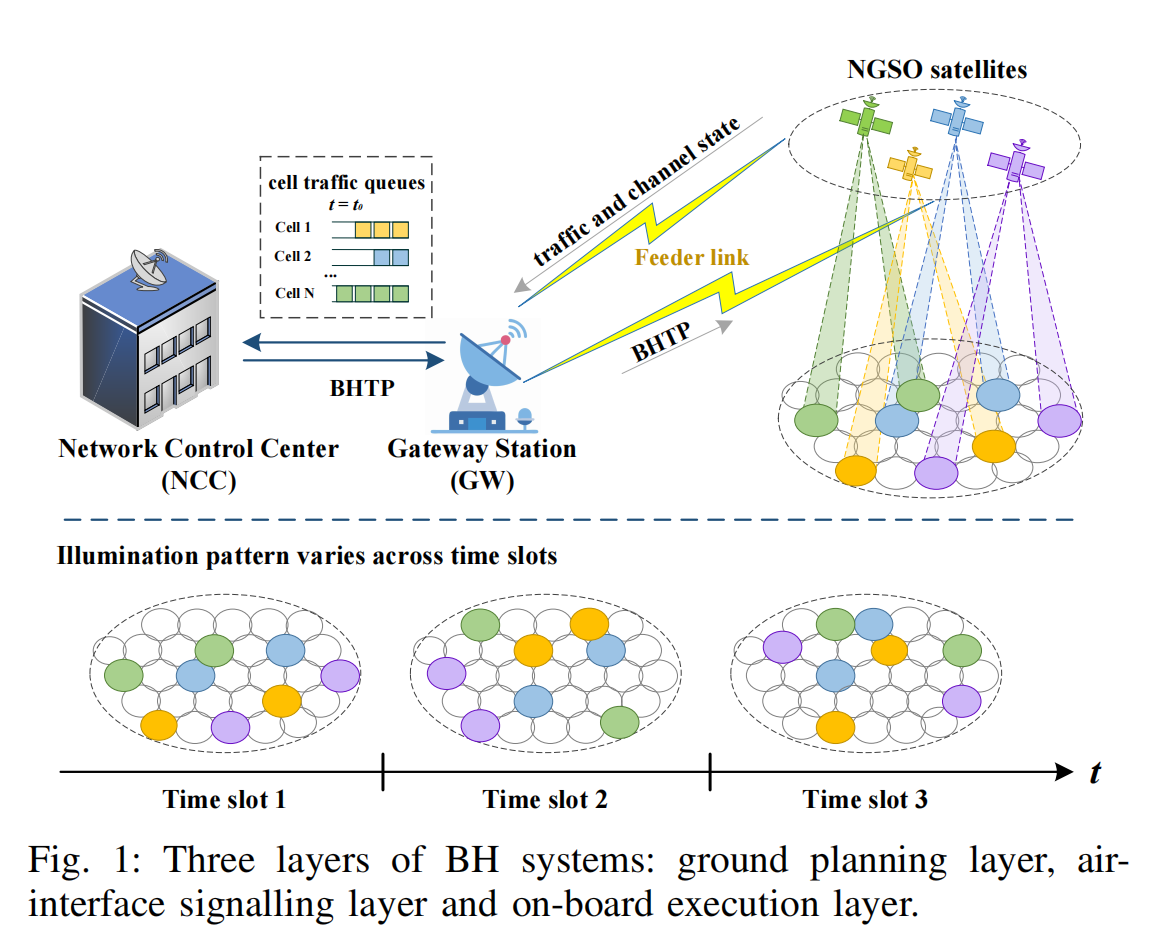

### B. 波束跳变时间计划（BHTP）

在采用预调度的 DVB-S2X BH 系统中，多个波束跳变业务信道（BHTC）并行运行并周期性重复，以服务不同的小区簇。每个 BHTC 根据波束跳变时间计划（BHTP）对其簇内的小区进行波束照射。BHTP 为一个完整跳变周期内的每个时隙规定两项内容：1）待照射的小区；2）对应的驻留时间 [4]。为简化起见，我们将驻留时间设为时隙长度 [14]。因此，BHTP 完整描述了逐时隙的波束照射序列。卫星从网关站接收到 BHTP 后，会循环执行该计划，直到新的 BHTP 到达。图 2 展示了 BHTP 的详细结构。

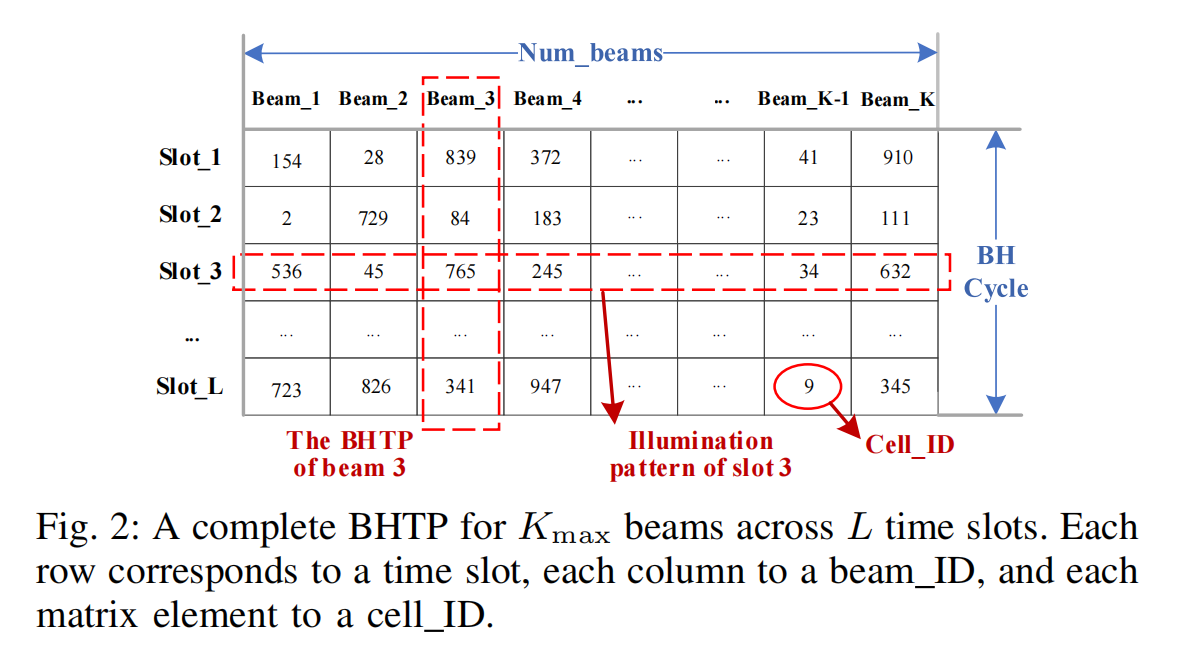

### C. 时隙与周期配置

物理层遵循 DVB-S2X 附录 E 的超帧配置，系统采用突发模式下行传输。根据 Starlink 向 FCC 提交的报告，我们将单波束净比特率设为 200 Mbps，并采用码率为 3/4 的 16-APSK 作为基准调制编码方案（MODCOD）。附录 E 定义的固定超帧长度为 $L_{\mathrm{SF}} = 612{,}540$ 个符号。该数值意味着 BH 驻留时间的物理下限约为 10 ms。这一下限保证了同步字段的完整对齐。

我们将 BH 时隙设为 30 ms。每个时隙聚合三个超帧，并预留约 2 ms 的保护间隔，以容纳时钟漂移并减少波束切换开销。在 30 ms 的时隙内，系统可以在多种 MODCOD 之间切换，例如 16-APSK 3/4 和 8-PSK 5/6，从而提高链路自适应能力。为满足小区重访时间约束，我们将一个 BH 周期设为 20 个时隙，总时长为 600 ms，如图 3 所示。轨道高度为 550 km 的卫星，其可见时间窗口约为 300 s，远长于该周期。这一配置为动态业务流量提供了充足的时空分辨率。

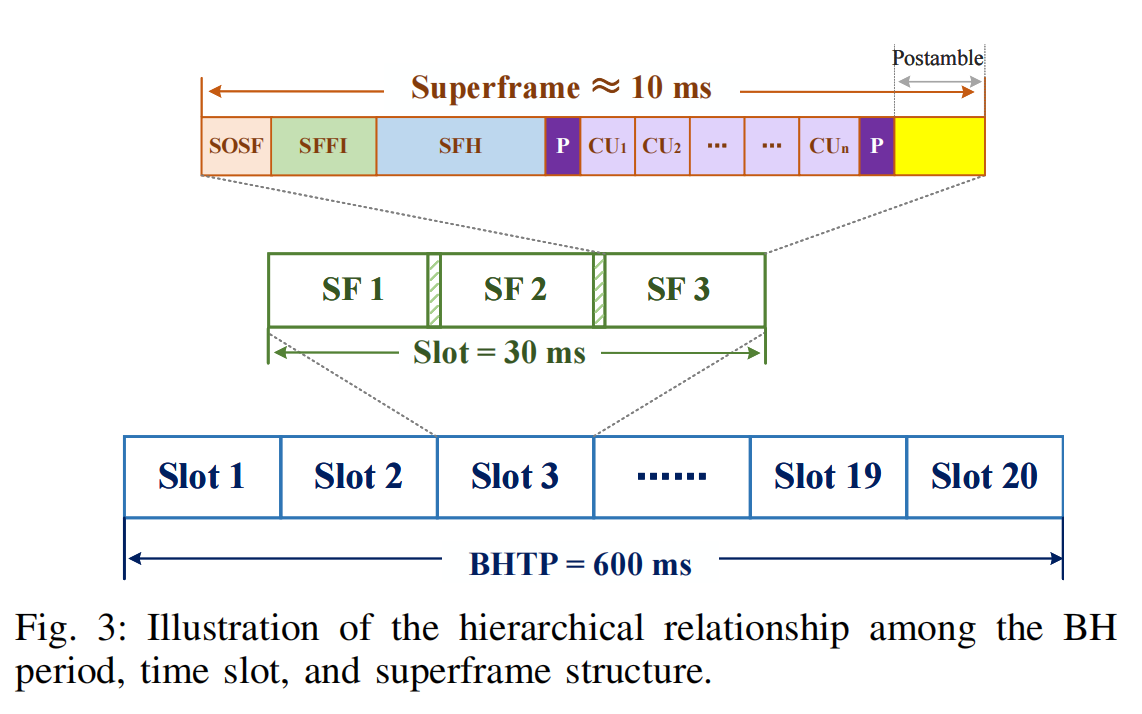

### D. 粒子群优化（PSO）

所提出的 Aidos 受到粒子群优化（PSO）的启发。PSO 是一种受群体智能启发、基于种群的元启发式算法。该算法维护一个粒子群，每个粒子具有位置和速度，分别表示一个候选解及其更新方向。粒子利用两类信息进行移动：自身的历史最优位置 $p_{\mathrm{best}}$，以及粒子群所发现的最优位置 $g_{\mathrm{best}}$。主要流程如下：首先，评估 $N_p$ 个粒子的适应度。随后，每一代按照“评估 → 更新 $p_{\mathrm{best}}$ 与 Pareto 档案 → 个性化选择 $g_{\mathrm{best}}$ → 粒子扰动”的流程进行迭代。达到预设的迭代次数上限后，从精英档案中选择最佳 Pareto 解作为输出。

### E. 现有框架及其问题

各标准组织从不同角度支持了 BH 技术。DVB-S2X 附录 E 在空口层定义了面向波束跳变的超帧（SF），并规定了如何在控制字段中承载 BHTP。ITU-R 为工作于 Ku 频段的 NGSO 多波束天线提供了参考辐射方向图。3GPP Release 17/18/19 增强了 NR-NTN 中的波束管理流程，以适应卫星侧所需的快速波束切换。

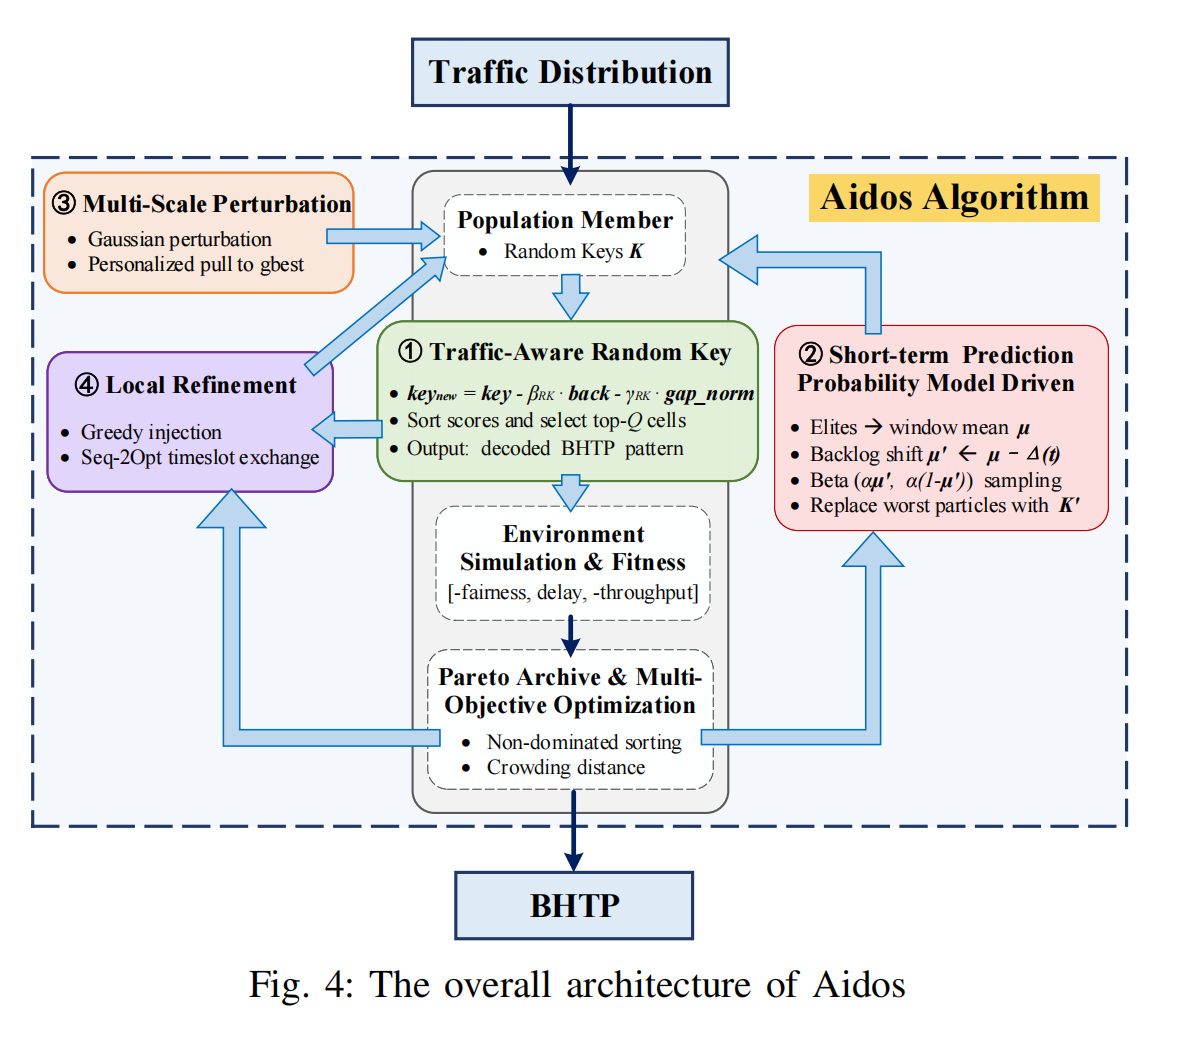

早期实际系统采用轮询调度 [15] 和随机调度 [16]。这些方法易于实现，但吞吐量较低。贪心启发式算法 [17] 同样具有计算速度快的优点。然而，这类算法忽略了非线性耦合关系，且缺乏全局信息，因此无法在 NP 难搜索空间中实现最大吞吐量。当前先进研究采用 GA [10] 等元启发式搜索方法以及 MADRL。GA 的计算复杂度较高，无法支持大规模场景下的在线计算。MADRL 在规模扩大时也无法收敛。Q-learning 和 DQN 等基于价值的方法需要在离散动作集合上执行最大化操作。在大规模场景中，每个时隙的动作空间规模增至 $\binom{N_c}{B}$，使得此类方法难以实现 [12] [13] [18] [19] [20] [21]。MAPPO 等演员–评论家方法依赖集中式评论家，其不断增大的全局状态空间与联合动作空间阻碍了高效、稳定的训练 [22] [23]。为解决这些问题，我们提出 Aidos，以在大规模场景下高效计算 BHTP。

## III. 设计概述

为计算大规模场景下的 BHTP，我们提出了一种混合优化算法 Aidos。该算法采用基于种群的多目标搜索，通过迭代不断改进 BHTP。在每一代中，算法评估种群的适应度，更新个体历史最优解与 Pareto 档案，随后为每个个体分配个性化参考解，以指导下一次更新。外层循环搜索由表 II 中的粒子群规模 $N_p$、迭代预算 $N_{\mathrm{iter}}$ 以及更新系数 $(w_{\mathrm{in}}, c_1, c_2)$ 进行配置。为增强搜索能力，Aidos 集成了四个协同模块，分别用于编码、概率引导、局部加速和步长自适应。这些模块使算法能够在大规模场景下快速收敛至高质量的 BHTP 解。算法的总体结构如图 4 所示。

### A. 业务流量感知的随机键编码模块（TARK）

如图 2 所示，BHTP 可以建模为一个高维离散矩阵，每个元素存储一个小区标识符（cell_ID）。离散决策不适合直接进行基于种群的搜索，因此 Aidos 引入了 TARK 模块。对于每个时隙–小区对，该模块生成一个位于 $(0,1)$ 内的键值，并构成形状为 `[num_slots, num_cells]` 的连续键矩阵。该矩阵对所有小区的服务优先级顺序进行编码。

在解码过程中，算法根据键值、当前积压业务量权重以及重访间隔计算综合优先级。随后，系统根据该优先级为每个时隙选择待覆盖的小区，得到满足约束的 BHTP。该方法保留了解空间结构，并将热点偏好与公平性嵌入连续域，使搜索过程更加平滑。

### B. 短期预测概率模型驱动的重采样模块（STP-PMD）

每隔 $T_{\mathrm{PMD}}$ 代，Aidos 在完成适应度评估与 Pareto 档案更新后激活该模块，以改进后续的 BHTP 迭代，其中 $T_{\mathrm{PMD}}$ 为 STP-PMD 的触发间隔。该模块从 Pareto 档案中选取排名前 $\rho = 20\%$ 的精英随机键矩阵，以估计时隙–小区选择模式。这些精英解包含有关时隙–小区对有效服务的有用时空先验信息。

通过计算键值的滑动窗口均值，该模块以经验方式估计时隙–小区占用概率，随后利用短期业务流量预测与积压业务量对均值进行调整。利用修正后的占用概率 $\mu'$，我们构建融合先验信息的概率模型 $\operatorname{Beta}(\alpha\mu', \alpha(1-\mu'))$。其中，$\operatorname{Beta}(a,b)$ 表示定义在 $(0,1)$ 上、形状参数为 $a>0$ 和 $b>0$ 的 Beta 分布，详见第 IV.C 节。

我们从该模型中采样新的随机键矩阵，并替换适应度最差的解。通过估计时隙–小区占用概率，并周期性地注入符合热点分布与时间统计特征的布局，该模块加速了多目标优化的收敛。

### C. 局部精细优化模块（LR）

LR 模块每隔 $T_{\mathrm{LR}}$ 代触发一次，以快速推进 Pareto 前沿。该模块首先选择拥挤程度高且适应度较差的个体，随后对其 BHTP 直接执行两种操作：

1. **贪心注入：** 使用当前积压业务量最大的小区集合覆盖选定的波束列，以缓解队列压力。
2. **Seq-2Opt：** 交换满足 $|t_1-t_2|\leq 3$ 的两个完整时隙行；若估计吞吐量有所提高，则接受该交换。

经过列覆盖与行交换后，BHTP 得到局部改进。

### D. 多尺度扰动模块（MSP）

MSP 模块在每一代结束时作用于 BHTP 随机键矩阵，并通过多尺度扰动维持探索能力。首先，该模块向整个矩阵添加高斯噪声，以生成多样化的时隙–小区优先级模式。其次，以固定概率将扰动后的矩阵向个性化引导解移动，以避免过度漂移。最后，依据 1/5 成功规则更新粒子 $i$ 的个体步长 $\sigma_i$，其中 $\sigma_i$ 控制后续对各个键值施加的高斯扰动幅度。该过程保持了种群多样性并提高了收敛效率，从而得到高质量的 BHTP 解。

### 表 I：符号及说明

| 符号 | 定义 |
|---|---|
| $\mathcal{N}$ | 卫星数量 |
| $\mathcal{M}$ | 小区数量 |
| $K_{\max}$ | 每颗卫星最多可同时激活的波束数量 |
| $Q$ | 每个时隙可调度的波束总数 |
| $\mathcal{L}$ | 时隙数量 |
| $\mathbf{B}$ | 全局 BHTP 矩阵 |
| $T_{\mathrm{slot}}$ | 单个时隙的持续时间 |
| $T_{\mathrm{cycle}}$ | 一个 BHTP 周期的持续时间 |
| $D_{m,i}$ | 小区 $m$ 在时隙 $i$ 的业务需求 |
| $D_{m,0}$ | 小区 $m$ 在周期开始时的初始业务需求 |
| $C_{m,i}$ | 小区 $m$ 在时隙 $i$ 的信道容量 |
| $A_{m,i}$ | 小区 $m$ 在时隙 $i$ 的速率松弛增益 |
| $L_{\mathrm{pkt}}$ | 固定数据包长度 |
| $\lambda_{m,i}^{\mathrm{tot}}$ | 小区 $m$ 在时隙 $i$ 的数据包总到达率 |
| $\lambda_{m,i}^{\mathrm{rt}}$ | 小区 $m$ 在时隙 $i$ 的实时数据包到达率 |
| $\mu_{m,i}$ | 小区 $m$ 在时隙 $i$ 的服务率 |
| $b_{i,q}$ | BHTP 中时隙 $i$ 分配给全局波束 $q$ 的小区 |
| $F_1,F_2,F_3$ | 公平性、时延和吞吐量目标 |

## IV. 算法设计

本节介绍 Aidos 的系统模型以及各模块的设计细节。

### A. 问题建模

本研究关注 NGSO 星座下行链路的集中式 BH 调度。设地面控制中心的最小接收仰角为 $\theta$。在任意时隙内，可见卫星数量为 $N$，以 $n=1,2,\ldots,N$ 为索引。控制中心统一为这 $N$ 颗卫星分配波束。利用 H3 地理空间索引库，以分辨率等级 5 将地球表面离散为六边形小区，所得小区面积与 Starlink 点波束的覆盖面积接近。叠加所有可见卫星的瞬时视场，可得到 $M$ 个地面小区，以 $m=1,2,\ldots,M$ 为索引。每颗卫星最多可同时启用 $K_{\max}$ 个点波束。因此，每个时隙可调度的波束总数为 $Q=NK_{\max}$。

本研究采用的星地通信模型遵循文献 [12] [13] 中的通用框架。BHTP 是 Aidos 的核心决策变量，定义为：

$$
\mathbf{B}=[b_{i,q}]
\in \{0,1,2,\ldots,M\}^{L\times Q}
\tag{1}
$$

其中，$i=1,\ldots,L$ 和 $q=1,\ldots,Q$ 分别表示时隙索引与全局波束索引。$Q$ 列按卫星分组，第 $(n-1)K_{\max}+1$ 列至第 $nK_{\max}$ 列对应卫星 $n$。每个元素 $b_{i,q}$ 表示时隙 $i$ 中波束 $q$ 的分配情况，其中 $b_{i,q}=m$ 表示服务小区 $m$，$b_{i,q}=0$ 表示空闲。此外，$L=T_{\mathrm{cycle}}/T_{\mathrm{slot}}$。

本研究考虑的优化目标包括公平性、实时数据包平均时延以及吞吐量。BHTP 确定后，在每个调度周期结束时评估这三个指标。公平性指标定义如下：

$$
F_1(\mathbf{B})
=
\sum_{m=1}^{M}
\frac{
\sum_{i=1}^{L}C_{m,i}(\mathbf{B})T_{\mathrm{slot}}
}{
D_{m,0}+\sum_{i=1}^{L}A_{m,i}
}
\tag{2}
$$

其中，$D_{m,0}$ 表示小区 $m$ 在周期开始时尚未得到服务的业务需求；$C_{m,i}(\mathbf{B})\cdot T_{\mathrm{slot}}$ 表示时隙 $i$ 内为小区 $m$ 服务的数据量；$A_{m,i}$ 表示小区 $m$ 在时隙 $i$ 内的速率松弛增益，假设其服从泊松分布。

与已有研究一致，BH 服务过程通常建模为 M/M/1 排队系统 [24]，其中下行波束的服务率为：

$$
\mu_{m,i}(\mathbf{B})
=
\frac{C_{m,i}(\mathbf{B})}{L_{\mathrm{pkt}}}
\tag{3}
$$

其中，$L_{\mathrm{pkt}}$ 表示固定数据包长度。对于小区 $m$，时隙 $i$ 的数据包总到达率记为 $\lambda_{m,i}^{\mathrm{tot}}$。当 $\lambda_{m,i}^{\mathrm{tot}}<\mu_{m,i}(\mathbf{B})$ 时，平均排队时延为：

$$
W_{m,i}(\mathbf{B})
=
\frac{1}{
\mu_{m,i}(\mathbf{B})-\lambda_{m,i}^{\mathrm{tot}}
}
\tag{4}
$$

根据 NGMN 联盟报告的混合业务构成 [25] [26]，我们假设实时业务占总需求的 30%。对于时延截止期限为 $\tau_{\max}$ 的实时业务，排队时延超过 $\tau_{\max}$ 的数据包被视为丢弃。在目标函数中，为丢弃的数据包赋予固定的惩罚时延 $\kappa\tau_{\max}$，其中 $\kappa>1$ 为惩罚因子，本文取 $\kappa=10$。带惩罚的时延定义为：

$$
\widetilde{W}_{m,i}(\mathbf{B})
=
\begin{cases}
W_{m,i}(\mathbf{B}),
& W_{m,i}(\mathbf{B})<\tau_{\max},\\
\kappa\tau_{\max},
& W_{m,i}(\mathbf{B})\geq\tau_{\max}.
\end{cases}
\tag{5}
$$

于是，实时数据包的平均时延目标为：

$$
F_2(\mathbf{B})
=
\frac{
\sum_{m=1}^{M}\sum_{i=1}^{L}
\lambda_{m,i}^{\mathrm{rt}}
\widetilde{W}_{m,i}(\mathbf{B})
}{
\sum_{m=1}^{M}\sum_{i=1}^{L}
\lambda_{m,i}^{\mathrm{rt}}
}
\tag{6}
$$

其中，实时业务的平均到达率为 $\lambda_{m,i}^{\mathrm{rt}}=0.3\lambda_{m,i}^{\mathrm{tot}}$。

一个 BH 周期内的系统总吞吐量为：

$$
F_3(\mathbf{B})
=
\sum_{m=1}^{M}\sum_{i=1}^{L}
C_{m,i}(\mathbf{B})T_{\mathrm{slot}}
\tag{7}
$$

综上，本研究构建如下多目标优化问题：

$$
\mathcal{P}_1:
\min_{\mathbf{B}}
\left[
-F_1(\mathbf{B}),
F_2(\mathbf{B}),
-F_3(\mathbf{B})
\right]
\tag{8}
$$

$$
\mathrm{C}_1:
\sum_{q=1}^{Q}
\mathbf{1}_{\{b_{i,q}=m\}}
\leq 1,
\qquad \forall m,i,
\tag{9}
$$

$$
\mathrm{C}_2:
\sum_{q=(n-1)K_{\max}+1}^{nK_{\max}}
\sum_{m=1}^{M}
\mathbf{1}_{\{b_{i,q}=m\}}
\leq K_{\max},
\qquad \forall n,i.
\tag{10}
$$

其中，$F_1$、$F_2$ 和 $F_3$ 分别由式（2）、（6）和（7）定义。Aidos 在 Pareto 意义下优化这一三维目标向量。约束 C1–C2 保证调度的可行性。具体而言，C1 要求每个小区在每个时隙内最多由一个全局波束提供服务。C2 是与全局 BHTP 表示一致的结构可行性约束，确保与卫星 $n$ 关联的波束分配保持在其专属的 $K_{\max}$ 个波束列组成的块内。

### 算法 1：业务流量感知的随机键解码

**输入：** 键矩阵 $K_{L\times M}$；时隙数量 $L$；小区数量 $M$；波束数量 $Q$；积压业务量权重 $back$；$\Delta t$ 计数器 $gap_{1..M}$；$\beta_{\mathrm{RK}}$、$\gamma_{\mathrm{RK}}$。

**输出：** 波束照射模式 $Pattern_{L\times Q}$；更新后的 $gap$。

```text
1  对 t ← 1 到 L 执行：
2      gap_norm ← (gap − min(gap)) / (max(gap) − min(gap) + ε)
3      score ← K[t, :] − β_RK · back − γ_RK · gap_norm
4      order ← argsort(score)
5      sel ← order[1...Q]
6      Pattern[t, :] ← sel
7      gap ← gap + 1；gap[sel] ← 0
```

### 算法 2：业务流量感知的随机键编码

**输入：** 波束照射模式 $Pattern_{L\times Q}$；时隙数量 $L$；小区数量 $M$；波束数量 $Q$。

**输出：** 编码后的键矩阵 $K'_{L\times M}$。

```text
1  K′ ← 0_(L×M)
2  对 t ← 1 到 L 执行：
3      ranks ← rank_ascending(Pattern[t, :]) / M
4      K′[t, Pattern[t, :]] ← ranks
5      mask ← {1, ..., M} \ Pattern[t, :]
6      K′[t, mask] ← 0.8 + 0.2 · UniformRand(|mask|)
```

### B. 业务流量感知的随机键编码模块（TARK）

求解 BHTP 是一个高维离散组合优化问题。在离散空间中直接更新粒子的速度和位置，无法实现平滑改进，且往往导致过早收敛。因此，我们设计了一种业务流量感知的随机键编码，将离散分配映射至连续域。这种表示方式提高了探索效率。

具体而言，每个种群个体持有一个形状为 `[num_slots, num_cells]` 的随机键矩阵 $K$，其中每个元素均位于区间 $(0,1)$ 内。$key_{t,c}$ 表示时隙 $t$ 中小区 $c$ 的优先级键值，数值越小，优先级越高。优化过程在连续键空间中进行，离散波束分配则在解码过程中生成。

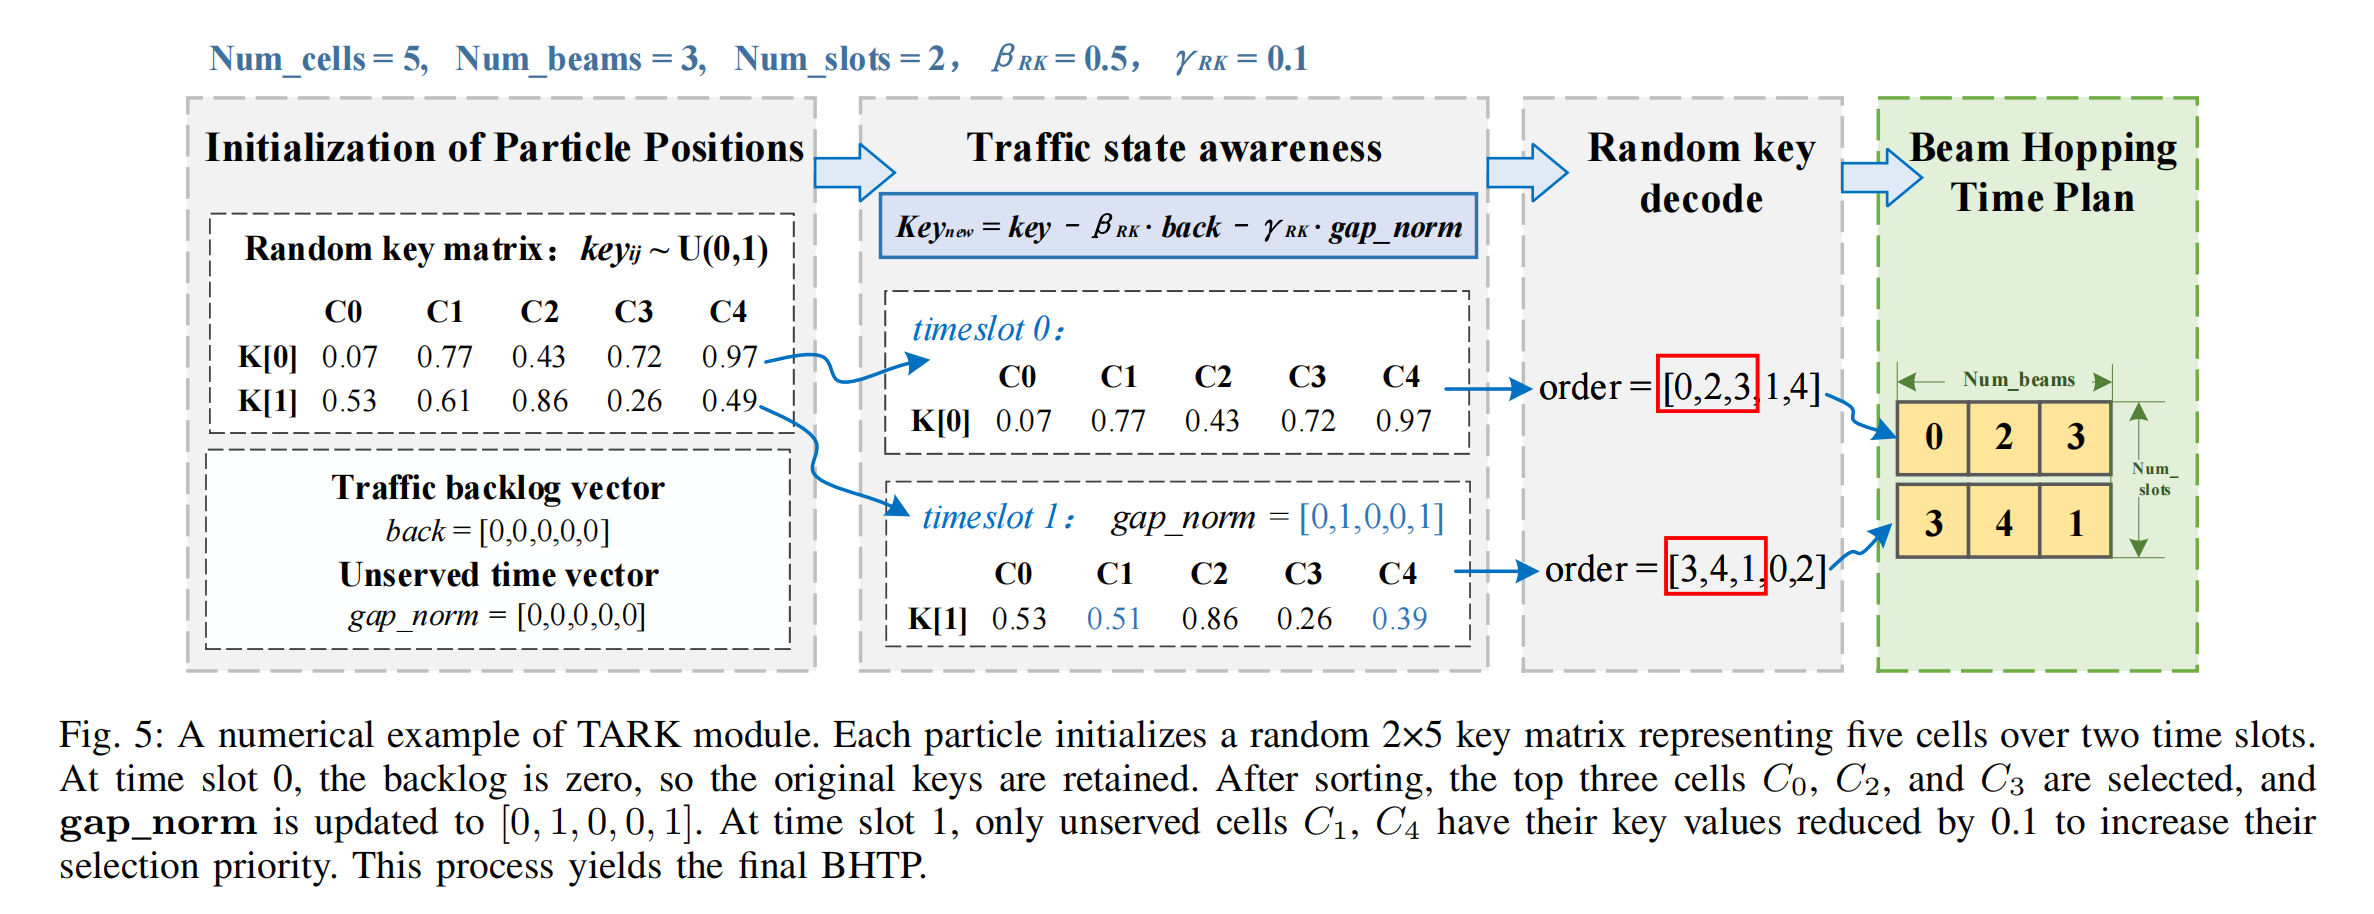

解码时，对每个时隙执行以下三个步骤：

1. 利用积压业务量向量 $\mathbf{back}$ 和未服务间隔向量 $\mathbf{gap\_norm}$，更新键值行向量：

$$
\mathbf{key}_t^{\mathrm{new}}
=
\mathbf{key}_t
-
\beta_{\mathrm{RK}}\mathbf{back}
-
\gamma_{\mathrm{RK}}\mathbf{gap\_norm}
\tag{11}
$$

其中，$\beta_{\mathrm{RK}}$ 和 $\gamma_{\mathrm{RK}}$ 为随机键模块的权重系数。

2. 根据更新后的键值对该行进行排序，并按升序选择波束，形成该时隙的波束照射模式。
3. 更新 $\mathbf{gap\_norm}$，并进入下一个时隙。

完成所有时隙的波束选择后，即得到最终的 BHTP。该模块将基于积压业务量和等待时间的公平性直接嵌入解码逻辑。这一设计动态平衡了热点区域与低负载区域之间的服务频率。

算法 1 给出了 TARK 解码的伪代码。第 2 行计算解码所需的信息：遍历各时隙，并对重访间隔进行归一化，得到 $\mathbf{gap\_norm}$。第 3–5 行执行优先级评估与候选选择，第 6–7 行更新状态。

解码算法的时间复杂度如下：第 2–3 行需要 $O(M)$ 时间；第 4 行的 `argsort` 调用开销为 $O(M\log M)$；第 5–7 行的开销为 $O(M+Q)$。由于循环执行 $L$ 个时隙，总时间复杂度为 $O(LM\log M)$。

算法 2 给出了 TARK 编码的伪代码。第 1 行将编码后的键矩阵 $K'$ 初始化为零。第 2–4 行按照升序排名，为当前时隙选中的小区分配较小的键值，并将其写回对应位置。第 5–6 行为未选中的小区分配位于 $[0.8,1.0)$ 内的较大随机键值。

编码过程的时间复杂度如下：第 1 行需要 $O(LM)$ 时间；第 2–4 行的合计开销为 $O(Q\log Q+Q)$；第 5–6 行的开销为 $O(M)$。对于全部 $L$ 个时隙，总时间复杂度为 $O(L(Q\log Q+M))$。由于实际中 $M\gg Q$，主导项为 $O(LM)$。

**示例分析：** 如图 5 所示，首先为每个粒子生成一个随机的 $2\times5$ 键矩阵，表示五个小区在两个时隙上的连续编码。在时隙 $t$，根据 $\mathbf{back}$ 和 $\mathbf{gap\_norm}$ 更新键值。在时隙 0，由于积压业务量为零，保留原始键值。将键值按升序排列后，选择排名前三的小区 $C_0$、$C_2$ 和 $C_3$ 进行波束照射，并将 $\mathbf{gap\_norm}$ 更新为 $[0,1,0,0,1]$。进入时隙 1 后，再次更新键值。可以看到，只有上一时隙未得到服务的小区 $C_1$ 和 $C_4$ 的键值减小了 0.1，以提高它们在当前时隙排序中的相对优先级。随后，利用最终结果计算 BHTP。

### C. 短期预测概率模型驱动的重采样模块（STP-PMD）

为抑制种群个体聚集于局部最优解，并利用 BHTP 的时空结构，我们设计了 STP-PMD 模块，如图 6 所示。该模块每隔 $T_{\mathrm{PMD}}$ 代触发一次。首先，从 Pareto 档案中选取排名前 $\rho=20\%$ 的精英随机键矩阵。随后，对每个小区的队列应用指数平滑：

$$
\hat{q}_j(t)
=
\alpha_p d_j(t)
+
(1-\alpha_p)\hat{q}_j(t-1)
\tag{12}
$$

其中，$q_j(t)$ 表示小区 $j$ 在时隙 $t$ 的积压业务量；$d_j(t)$ 表示实际到达率。随后，生成短期队列预测：

$$
\hat{q}_j^{\mathrm{pred}}(t+1)
=
\hat{q}_j(t)
+
\beta_p
\left[
\hat{q}_j(t)-\hat{q}_j(t-1)
\right]
\tag{13}
$$

其中，$\alpha_p$ 和 $\beta_p$ 为该模块的系数。

对于选定的精英随机键矩阵，使用长度为 $w_p$（以时隙为单位）的重叠时间窗口，计算键值的局部均值 $\mu$。加入基于积压业务量与预测的偏移量，得到修正后的占用概率 $\mu'_{b,j}$：

$$
\mu'_{b,j}
=
\mu_{b,j}-\Delta_j(t)
\tag{14}
$$

$$
\Delta_j(t)
=
\beta_q\frac{q_j(t)}{q_{\max}}
+
\eta_e
\frac{
\hat{q}_j^{\mathrm{pred}}(t+1)-q_j(t)
}{
q_{\max}
},
\qquad \forall j,
\tag{15}
$$

其中，$\beta_q$ 和 $\eta_e$ 为加权系数，$q_{\max}$ 为积压业务量的归一化常数，$\Delta_j(t)$ 为小区 $j$ 的积压业务量与预测偏移量。该偏移量使滑动窗口均值偏向积压业务量更大、预测负载更高的小区。随后，我们构建概率模型 $X\sim\operatorname{Beta}(\alpha\mu',\alpha(1-\mu'))$，以引导重采样。其中，$\operatorname{Beta}(a,b)$ 表示定义在 $(0,1)$ 上、满足 $a>0$ 和 $b>0$ 的 Beta 分布。其概率密度函数（PDF）为：

$$
f_X(x;a,b)
=
\frac{1}{\mathrm{B}(a,b)}
x^{a-1}(1-x)^{b-1},
\qquad 0<x<1.
\tag{16}
$$

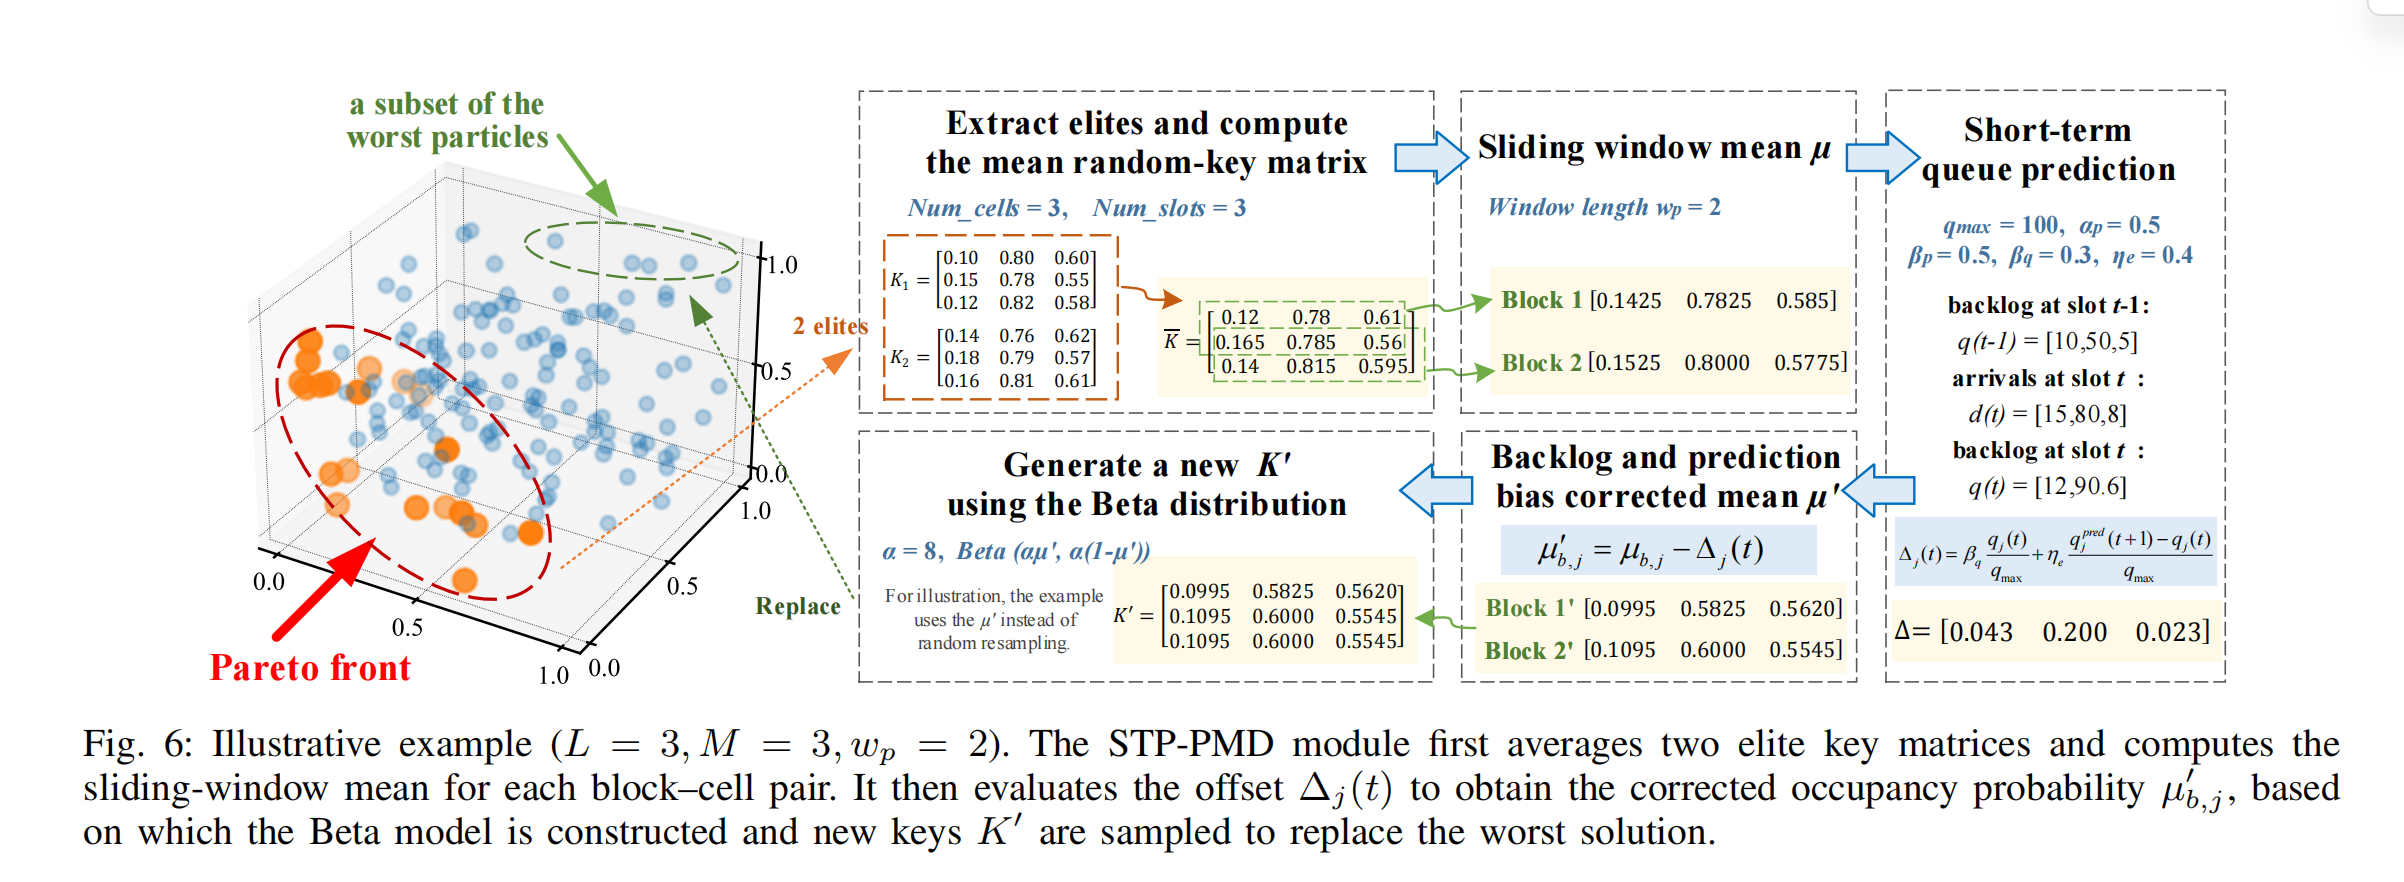

该参数化形式满足 $\mathbb{E}[X]=\mu'$ 和 $\operatorname{Var}(X)=\mu'(1-\mu')/(\alpha+1)$；因此，模型通过 $\mu'$ 承载时空先验信息，而 $\alpha$ 控制分布在 $\mu'$ 附近的集中程度。

最后，我们从模型中采样比例为 $\xi=20\%$ 的新随机键，以更新较差的粒子，并施加小幅扰动。这些样本用于替换适应度最差且拥挤程度最高的粒子。在解码过程中，算法优先选择历史上在相应时隙内带来收益的小区，同时保持时间平滑性与种群多样性。因此，算法更容易生成满足热点偏好与公平性约束的 BHTP。短期预测仅引导概率重采样的倾向，而不直接决定最终调度方案。因此，预测误差主要影响候选解的生成效率，最终解仍通过多目标评估与档案更新进行筛选。此外，在滚动在线重规划过程中，新观测到的业务流量会被纳入后续更新，有助于减轻业务流量突变的影响。

STP-PMD 模块的伪代码见算法 3。第 1–5 行执行初始化与标准迭代循环。当满足触发条件时，执行 PMD 分支。第 6–7 行根据非支配等级与拥挤程度选取比例为 $\rho$ 的精英个体。第 8–9 行计算短期队列预测。第 10–12 行计算窗口均值并加入偏移量，随后将这些占用概率映射为 Beta 分布参数。基于这一先验，第 13–18 行采样新的随机键并替换较差的解。

STP-PMD 的时间复杂度如下。单次触发产生四项主要开销：精英选择为 $O(|A|\log|A|)$；窗口统计为 $O(N_{\mathrm{blk}}Mw_p)$；采样并组装 $\xi|P|$ 个键矩阵为 $O(\xi|P|LM)$；较差解的选择与替换为 $O(|P|\log|P|)$。在 $G$ 代迭代中，每隔 $T_{\mathrm{PMD}}$ 代触发一次，总时间复杂度为：

$$
O\left(
\frac{G}{T_{\mathrm{PMD}}}
\left[
\xi|P|\cdot LM
+
(|A|+|P|)\log|P|
+
N_{\mathrm{blk}}Mw_p
\right]
\right)
\tag{17}
$$

**示例分析：** 如图 6 所示，我们设置 $L=3$ 个时隙、$M=3$ 个小区，窗口长度为 $w_p=2$。首先，算法取两个精英随机键矩阵，并计算其逐元素均值。随后，在“时间块 × 小区”上计算滑动窗口均值；对于时间块 1，使用第 1–2 行。给定积压业务量与到达量，算法通过预测公式计算修正量 $\Delta$，并更新时间块中的数值。设置 $\alpha=8$，构建 Beta 模型。为保证可复现性，该示例使用 Beta 分布的期望值代替随机采样，生成新的随机键矩阵 $K'$。最后，使用新生成的矩阵 $K'$ 替换最差解。

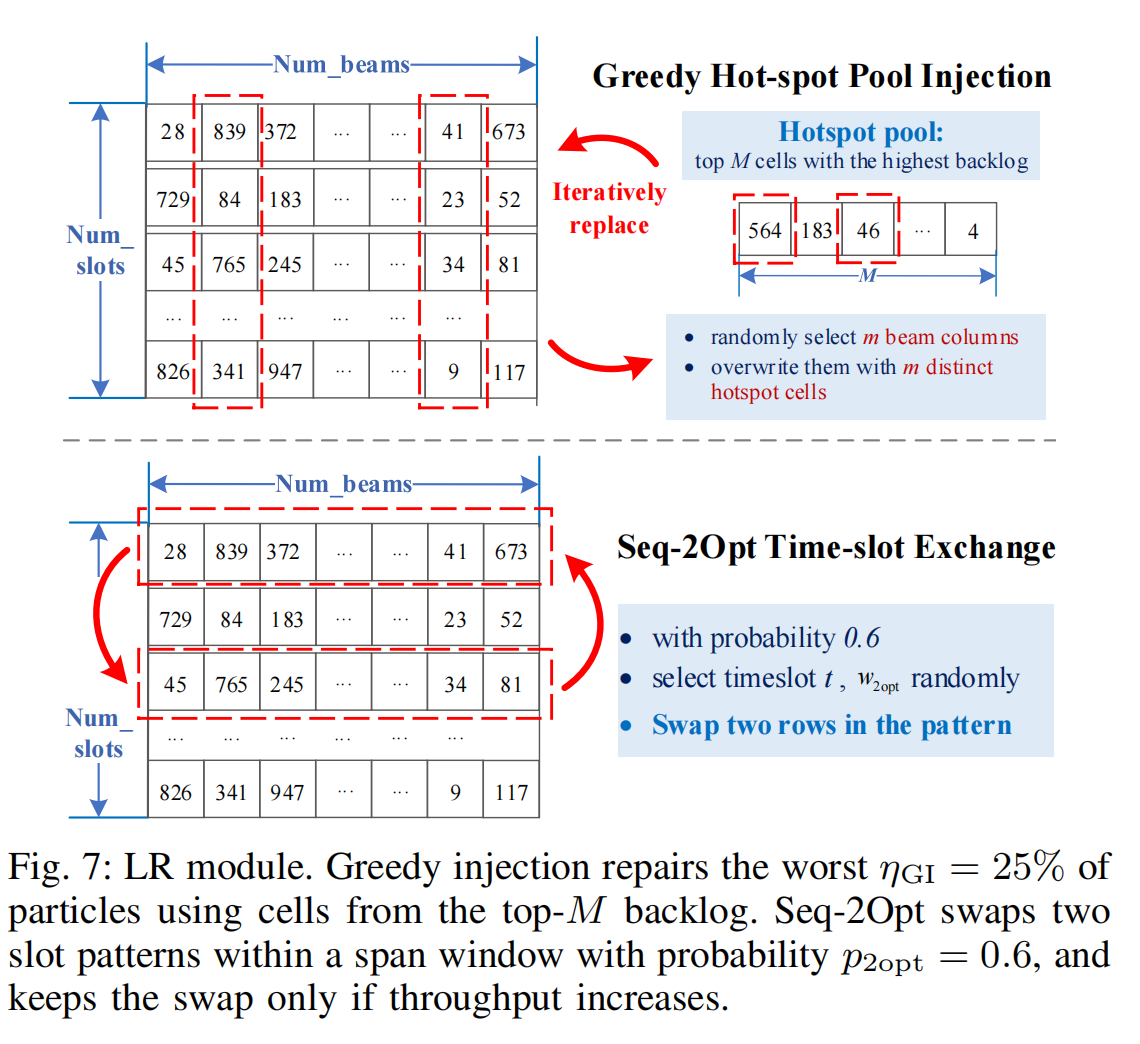

### D. 局部精细优化模块（LR）

为避免种群个体陷入次优区域而导致过早收敛，我们引入了 LR 模块，如图 7 所示。该模块包含两个算子：贪心注入与 Seq-2Opt 时隙交换。LR 模块每隔 $T_{\mathrm{LR}}$ 代激活一次。在贪心注入步骤中，按瞬时吞吐量对粒子进行排序，并选择最差的 $\eta_{\mathrm{GI}}=25\%$ 进行修复。随后，从负载最高的前 $M$ 个小区中构建热点池。最后，随机选择 $m$ 个波束列，并从池中选取互不相同的热点小区，分别覆盖 BHTP 中各个选定的完整列。

### 算法 3：短期预测概率模型驱动的重采样（STP-PMD）

**输入：** $P=\{K_1,\ldots,K_{|P|}\}$；档案 $A$；队列 $q_j(t)$；$w_p$；时隙数量 $L$；小区数量 $M$；时间块数量 $N_{\mathrm{blk}}$；精英比例 $\rho$；更新比例 $\xi$；$\alpha_p,\beta_p,\beta_q,\eta_e,\alpha,\sigma_i$；$q_{\max}$。

**输出：** 更新后的 $P$ 和 $A$。

```text
1   g ← 0；N_blk ← L − w_p + 1
2   当未满足终止条件时执行：
3       EvaluateFitness(P)
4       UpdatePbest(P)
5       UpdateArchive(A)
6       如果 g mod T_PMD = 0：
7           E ← 从 A 中选取排名前 ρ|P| 的精英个体
8           对每个小区 j 执行：
9               q̂_j(t) ← α_p d_j(t) + (1 − α_p)q̂_j(t − 1)
                q̂_j^pred(t + 1) ← q̂_j(t) + β_p[q̂_j(t) − q̂_j(t − 1)]
10          对 b ← 1 到 N_blk，j = 1...M 执行：
11              μ_(b,j) ← mean(E 的第 [b:b+w_p−1] 行、第 j 列)
12              Δ_j(t) ← β_q q_j(t)/q_max
                         + η_e[q̂_j^pred(t + 1) − q_j(t)]/q_max
13              μ′_(b,j) ← μ_(b,j) − Δ_j(t)
14          对 b ← 1 到 N_blk，j = 1...M 执行：
15              a_(b,j) ← αμ′_(b,j)；b_(b,j) ← α(1 − μ′_(b,j))
16          S_new ← ∅
17          对 k ← 1 到 ⌈ξ|P|⌉ 执行：
18              K′ ← SampleBeta(a_(b,j), b_(b,j)) + 𝒩(0, σ_i²)
19              S_new ← S_new ∪ {K′}
20          Worst ← SelectWorst(P, ⌈ξ|P|⌉)
21          Replace(Worst, S_new)
22      g ← g + 1
23  返回 P, A
```

随后，以概率 $p_{\mathrm{2opt}}=0.6$ 执行 Seq-2Opt 算子，对 BHTP 的时隙顺序进行局部调整。在长度为 $w_{\mathrm{2opt}}$（以时隙为单位）的窗口内，随机交换 BHTP 的两行。$w_{\mathrm{2opt}}$ 为行交换的邻域大小，每行表示一个时隙的波束照射模式。仅当交换后的吞吐量增加时，才接受该交换。

将所有已修改粒子的适应度设为 $+\infty$，以强制在下一代重新评估，并使其继续参与演化过程。这能够在保持探索能力的同时，快速清理热点积压业务并推进 Pareto 前沿。

### E. 多尺度扰动模块（MSP）

MSP 模块在种群层面施加粗尺度与细尺度扰动，同时在个体层面施加基于 $\sigma_i$ 的自适应扰动，其中 $\sigma_i$ 表示粒子 $i$ 的个体扰动步长。该模块在每一代结束时直接作用于 BHTP 随机键矩阵。初始化时，20% 的粒子采用粗步长，其余粒子采用细步长。随后，在每一代施加高斯扰动：

$$
\widetilde{key}_{t,c}
=
\left(key_{t,c}+\mathcal{N}(0,\sigma_i)\right)\bmod 1
\tag{18}
$$

以 0.5 的概率，将扰动后的粒子与个性化引导解取平均，以避免过度漂移。为自适应调整扰动尺度，在长度为 $w_\sigma$ 的窗口内采用 1/5 成功规则。当粒子 $i$ 在当前窗口内更新其个体历史最优解时，记录一次成功，并利用所得成功率调整 $\sigma_i$。因此，MSP 能够实现从粗尺度探索到细粒度精细优化的自适应过渡。

### F. 收敛性与计算复杂度

由于所研究的 BHTP 是一个高维离散多目标优化问题，我们将 Aidos 设计为基于种群的元启发式算法，而非确定性求解器。我们从精英档案保留、不劣化的局部精细优化以及有界引导扰动三个方面讨论其收敛行为，具体概括为以下命题。

**命题 1：精英档案保留。** 设 $A_t$ 表示第 $t$ 代的外部档案。如果 $A_{t+1}$ 保留当前档案与新生成候选解中的非支配解，并在必要时基于多样性进行截断，则先前找到的高质量解不会被受支配解替换。

该命题表明，档案更新采用精英保留机制。因此，高质量的非支配解能够在后续迭代过程中得到保留。

**命题 2：不劣化的局部精细优化。** 如果局部精细优化算子仅在接受准则有所改善时才接受新解，那么每个被接受的精细优化步骤在该准则下均不会使结果劣化。

在 Aidos 中，只有当交换后模式的吞吐量超过原始模式时，才接受 LR 模块中的 Seq-2Opt 操作。因此，局部精细优化是一种有方向的改进，而非随机扰动。

**命题 3：有界扰动尺度。** 如果每个粒子的扰动步长保持在预定义的有界范围内，则 MSP 模块在每一代中的更新幅度保持有界，不会因步长无限增长而发散。

由于步长始终有界，搜索逐渐从探索转向精细优化。

这些性质并不能证明算法收敛至全局 Pareto 最优解集。它们表明 Aidos 是一个结构化的迭代过程，这也与第 V 节中的实验收敛表现一致。

Aidos 每一代的计算开销由四部分构成：对全部 $|P|$ 个粒子进行 TARK 解码与适应度评估、MSP 更新，以及周期性触发的 STP-PMD 和 LR 模块。TARK 解码的复杂度已在前文给出，适应度评估的总开销记为 $C_{\mathrm{eval}}$。MSP 更新所有随机键矩阵，其复杂度为 $O(|P|\cdot LM)$。STP-PMD 的复杂度由式（17）给出，LR 的均摊复杂度为 $O(C_{\mathrm{LR}}/T_{\mathrm{LR}})$。因此，总体复杂度为：

$$
O\left(
|P|\cdot LM\log M
+
C_{\mathrm{eval}}
+
|P|\cdot LM
+
\frac{C_{\mathrm{LR}}}{T_{\mathrm{LR}}}
+
\frac{
\xi|P|\cdot LM
+
(|A|+|P|)\log|P|
+
N_{\mathrm{blk}}Mw_p
}{
T_{\mathrm{PMD}}
}
\right)
\tag{19}
$$

## V. 评估

### A. 实验设置

**仿真场景：** 本研究在第二代 Starlink 星座上评估 Aidos，以验证其在大规模卫星网络中的有效性。该星座采用高度为 550 km 的圆轨道，包含 72 个轨道面，每个轨道面有 22 颗卫星，共计 1,584 颗卫星。每颗卫星搭载 48 个独立的下行点波束，每个波束提供 200 Mbps 的峰值容量，具体参数见表 II。

### 表 II：仿真参数

| 参数 | 数值 |
|---|---|
| **通信参数** | |
| 卫星高度 $H$ | 550 km |
| 轨道面数量 | 72 |
| 每个轨道面的卫星数量 | 22 |
| 轨道倾角 | 53° |
| 每颗卫星的下行波束数量 | 48 |
| 每颗卫星的总容量 | 20 Gbps |
| 单波束容量 | 200 Mbps |
| 载波频率 $f_c$ | 20 GHz |
| 3 dB 波束宽度 $\theta_{\mathrm{3dB}}$ | 0.15° |
| 卫星发射等效全向辐射功率（EIRP） | 60 dBW |
| H3 分辨率等级 | 5 |
| 时隙长度 $T_{\mathrm{slot}}$ | 30 ms |
| BHTP 总时长 | 600 ms |
| **外层循环粒子群参数** | |
| 粒子数量 $N_p$ | 20 |
| 迭代次数 $N_{\mathrm{iter}}$ | 150 |
| 认知加速系数 $c_1$ | 1.5 |
| 社会加速系数 $c_2$ | 1.5 |
| 惯性权重 $w_{\mathrm{in}}$ | 0.7 |
| **模块参数** | |
| 精英比例 $\rho$ | 0.2 |
| 更新比例 $\xi$ | 0.2 |
| Beta 分布集中度参数 $\alpha$ | 4 |
| 窗口长度 $w_p,w_\sigma$ | 4，30 |
| 积压业务量权重 $\beta_q$ | 0.6 |
| 预测权重 $\eta_e$ | 0.4 |
| 贪心注入比例 $\eta_{\mathrm{GI}}$ | 0.25 |
| Seq-2Opt 概率 $p_{\mathrm{2opt}}$ | 0.6 |

表 II 中的预设比例是 Aidos 的模块级超参数。精英比例 $\rho=0.2$ 使 STP-PMD 聚焦于高质量 Pareto 解，同时保留足够的样本，以获得稳定的时隙–小区选择统计结果。更新比例 $\xi=0.2$ 用于注入通过 Beta 重采样生成、偏向高需求小区的候选解。在 LR 模块中，贪心注入修复最差的 $\eta_{\mathrm{GI}}=0.25$ 比例的粒子，以改进吞吐量较低的 BHTP；Seq-2Opt 则以 $p_{\mathrm{2opt}}=0.6$ 的概率执行局部 BHTP 行交换，以优化时隙顺序。

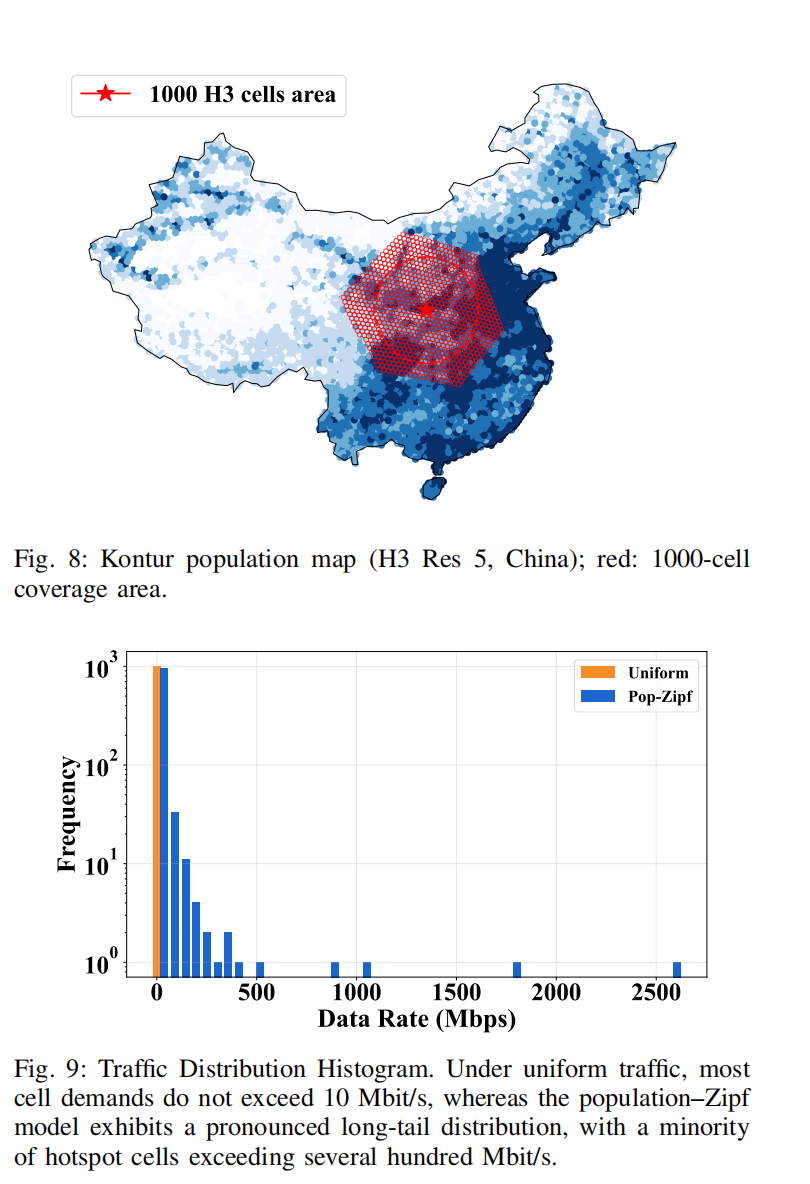

**数据集：** 由于缺乏公开的卫星网络业务流量数据集，我们基于 Kontur 世界人口网格和 3GPP TR 38.821 中的业务流量建模原则生成数据集。利用 H3 六边形网格库划分卫星覆盖范围内的地面小区。每个小区的初始业务需求由 Kontur 人口数据与 Zipf 定律加权相结合得到。随后，在每个时隙加入独立的泊松增量，以模拟突发到达。图 8 展示了基于 H3-5 网格的中国大陆人口热力图，图 9 展示了业务流量分布直方图。均匀分布基线主要集中在 0–10 Mbps 附近。人口–Zipf 场景呈现明显的长尾特征，少量小区的需求达到数百 Mbps。这些图表证实了显著的负载异质性：热点小区消耗了较大比例的容量。该数据集近似反映了真实条件，为评估 BH 调度算法提供了可信依据。

**总体性能：** 我们在整个 BH 周期内评估吞吐量与实时数据包平均时延。为量化 Aidos 在不同业务流量强度下的表现，我们将卫星总容量设为 $D$，并在地面需求为 $[0.2,0.4,0.6,0.8,1.0]\times D$ 的条件下评估性能，报告各性能指标的变化趋势。

将所提出的 Aidos 与以下五种基线 BH 方案进行比较：

1. **Random-BH：** 每个时隙随机选择 $K_{\max}$ 个小区，计算开销可忽略不计，作为性能下界基准。
2. **Greedy-BH：** 每个时隙选择积压业务量最高的前 $K_{\max}$ 个小区，以最大化瞬时吞吐量。
3. **MOGA-BH：** 将 BH 调度方案编码为染色体，通过选择、交叉和变异等遗传操作，使解逐代演化。
4. **SA-BH：** 模拟退火对当前解施加扰动，并根据温度调度以一定概率接受较差的解，以跳出局部最优；精确调整降温策略仍然至关重要。
5. **MADRL-BH：** 根据文献 [12]，采用 MADRL 算法计算每个时隙的波束照射模式。

**消融研究：** 为量化 Aidos 中四种关键机制的独立贡献，我们对 TARK、STP-PMD、LR 和 MSP 模块进行消融研究。每次禁用一个模块，同时保持其余流程与超参数不变。该过程产生四种对照变体，并以完整的 Aidos 作为基准。所有变体均在相同业务流量场景下，使用十个随机种子运行。我们记录主要性能指标与超体积（HV）曲线。

**收敛性：** 元启发式算法通过迭代优化提高解的质量。在实际应用中，收敛受到可用计算时间的限制。因此，我们对 SA-BH、MOGA-BH 和 Aidos 进行 300 次迭代评估，报告 10 次独立运行的均值与 95% 置信区间。所有实验均采用相同的 10 Gbps 业务负载。

**可扩展性：** 在 Starlink 和 OneWeb 等新一代 LEO 星座中，小区尺寸显著缩小，单颗卫星可覆盖数千个小区。因此，可扩展性是一项关键评估指标。我们在实际运行的 Starlink 星座条件下评估 Aidos，并将北京地面站（39.91° N，116.40° E）设为观测点。通过改变地面站的最小接收仰角，评估 Aidos 在多种场景下的可扩展性。

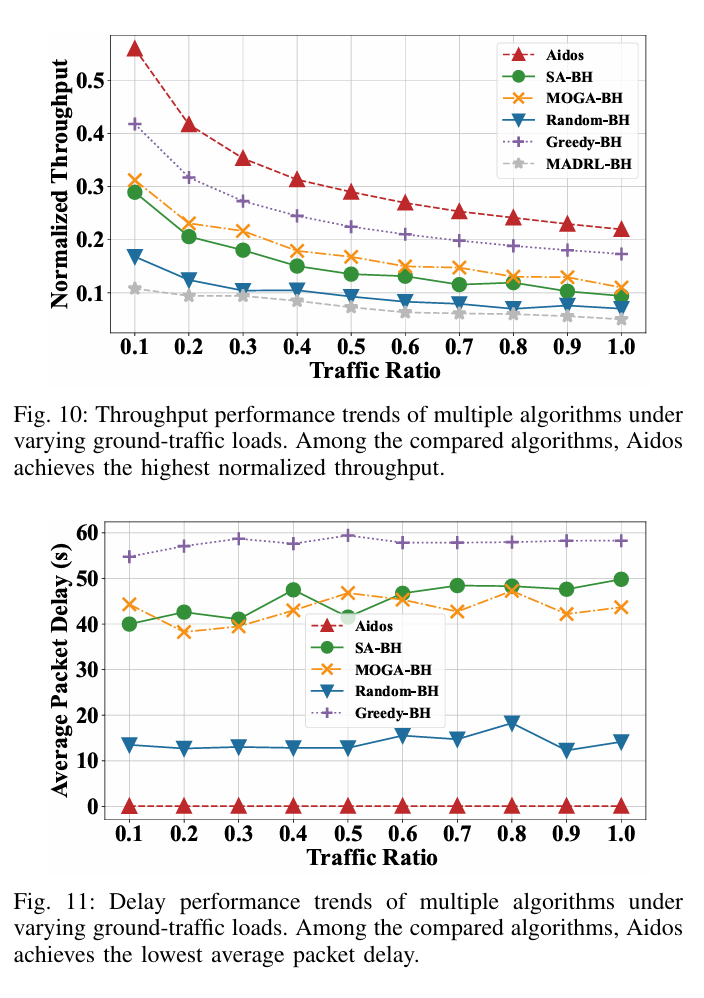

### B. 总体性能

实验结果展示了不同地面业务流量强度下的吞吐量与时延变化趋势。

如图 10 所示，Aidos 在吞吐量方面具有明显优势。当业务流量比为 0.1 时，Aidos 的吞吐量达到 0.559。相较于 SA-BH、MOGA-BH、Random-BH 和 Greedy-BH，其增益分别约为 93.5%、79.2%、232.1% 和 33.9%。随着业务流量比增加，所有算法的可用余量均减少，呈现一致的下降趋势。然而，Aidos 的性能下降幅度最小。即使在业务流量比为 1 的满负载条件下，Aidos 仍比表现第二好的 Greedy-BH 高出 26.67%。相比之下，MADRL-BH 表现最差，因为智能体未能学习到有效策略，这证实了该方法不适用于大规模 BH 场景。

图 11 展示了时延结果。Aidos 在不同业务流量水平下保持稳定的时延，且始终低于 70 ms，满足常见语音业务低于 150 ms 的时延目标 [27]。与 SA-BH、MOGA-BH、Random-BH 和 Greedy-BH 相比，Aidos 将平均时延降低了约 99.45%–99.9%。

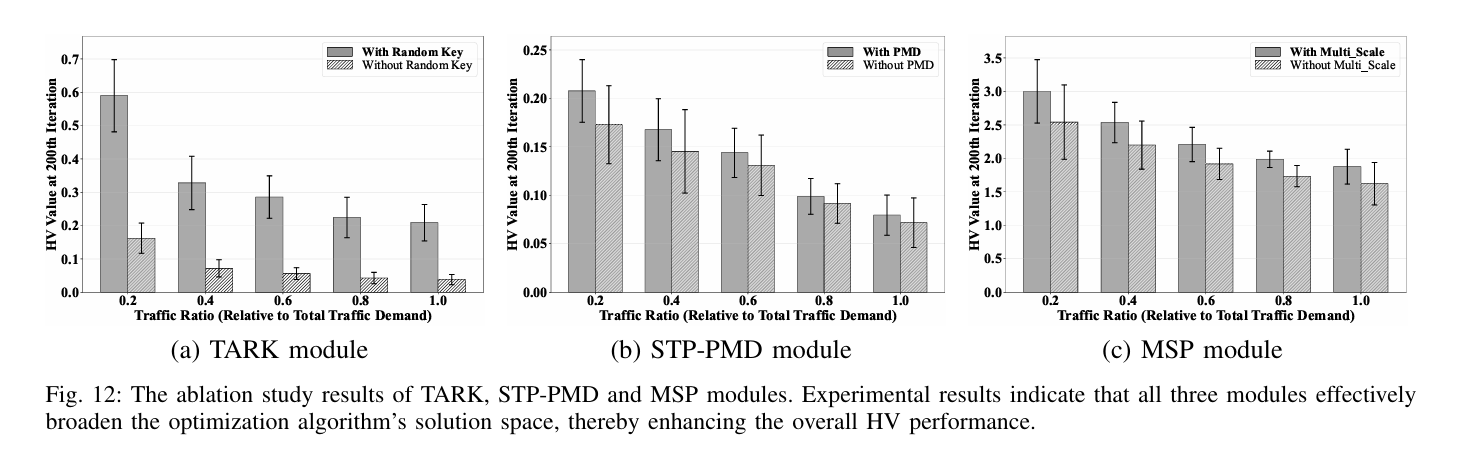

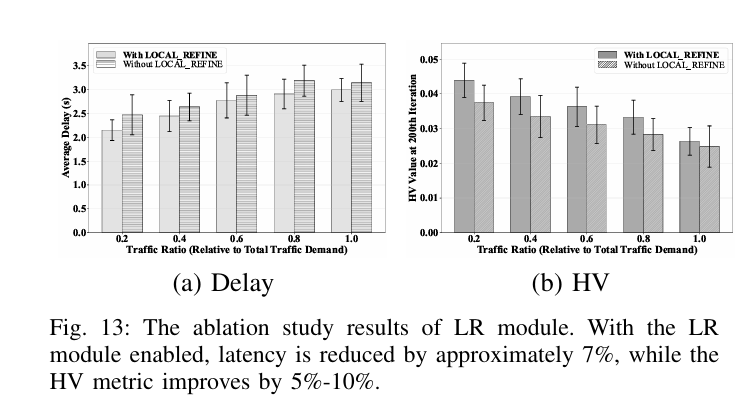

### C. 消融研究结果

图 12 和图 13 展示了 Aidos 四个关键模块的消融结果，并证实了它们的独立贡献。如图 12(a) 所示，TARK 模块是最关键的组成部分。它扩展了可搜索空间，并将 HV 提高了 40%–60%。图 12(b) 和图 12(c) 进一步表明，STP-PMD 与 MSP 均能增强种群多样性并加速收敛，其 HV 增益分别为 12%–25% 和 15%–30%。在图 13(a) 中，LR 模块对已收敛的解进行精细优化，在不损失吞吐量的情况下，将时延降低了约 7%。最后，图 13(b) 表明，局部精细优化还使总体 HV 提高了 5%–10%。

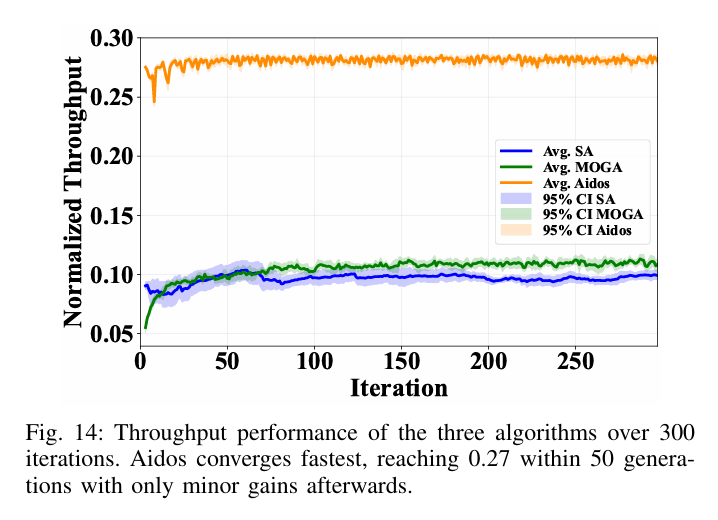

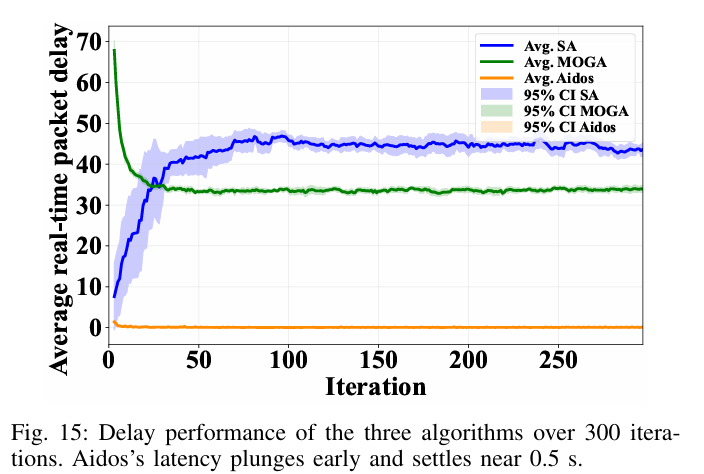

### D. 收敛性结果

图 14 和图 15 展示了 Aidos、SA-BH 和 MOGA-BH 在 300 次迭代中的吞吐量与时延表现。如图所示，Aidos 具有最佳的收敛特性。在吞吐量方面，Aidos 在 50 代内达到 0.27，并继续小幅提升，而 SA-BH 和 MOGA-BH 需要约 250 次迭代才能接近收敛。在时延方面，Aidos 在初始迭代阶段迅速下降，并稳定在约 100 ms。相比之下，MOGA-BH 在 40 代后才降至约 34 s，而 SA-BH 即使在 100 代后，仍在 45 s 附近缓慢波动。

Aidos 仅经过 50 次迭代便达到收敛阈值：连续 20 代的运行均值变化不超过 1%。MOGA-BH 需要 150 代，而 SA-BH 在 250 代后仍存在振荡。

Aidos 的标准差变化也最小，体现了其更好的稳定性。因此，300 次迭代足以覆盖三种算法的稳态阶段。采用基于目标阈值的早停规则，Aidos 可以将迭代次数上限设为 50 代，节省超过 65% 的计算预算。

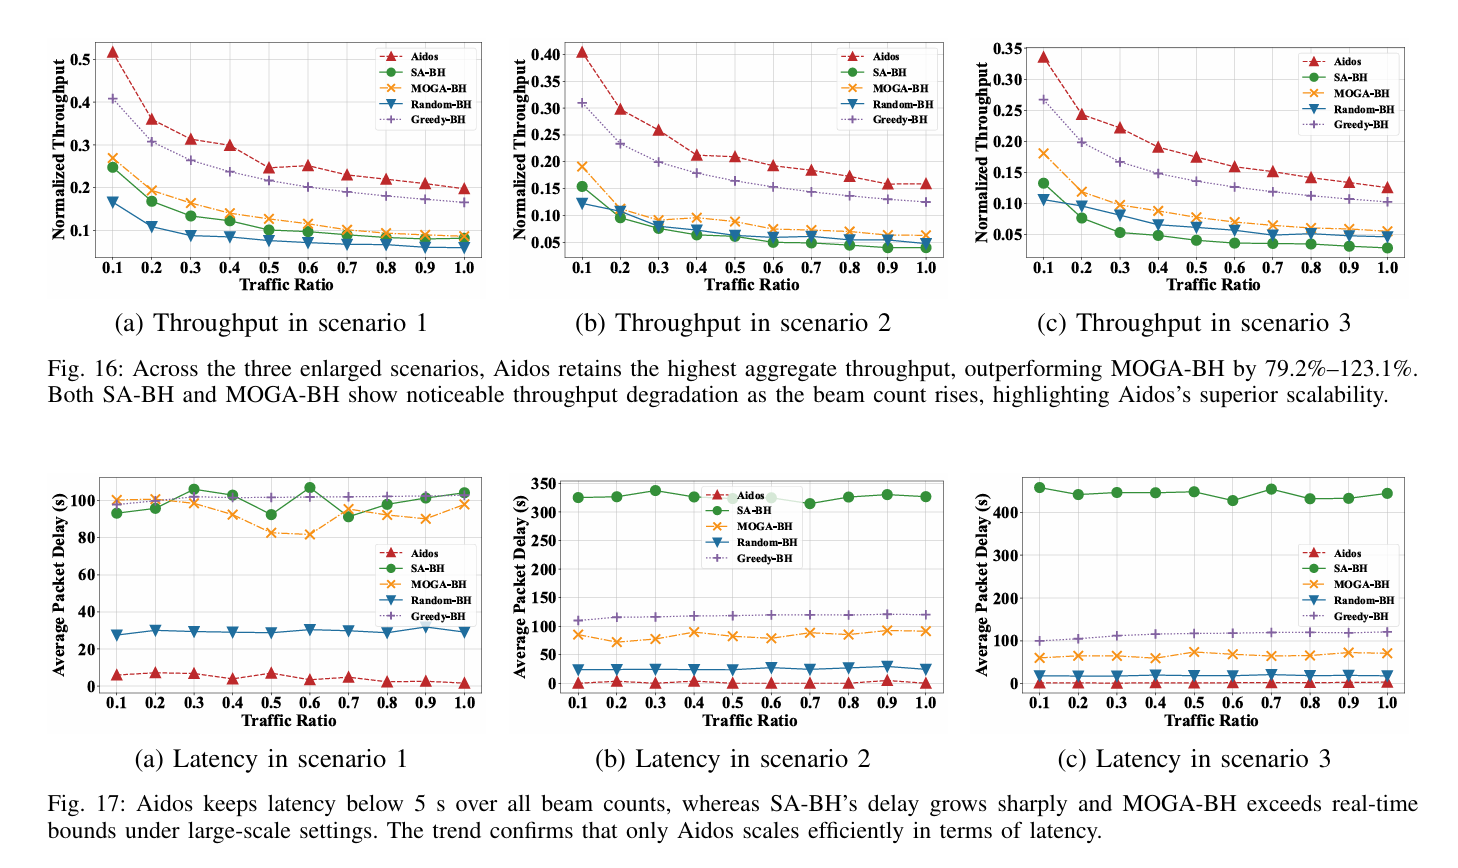

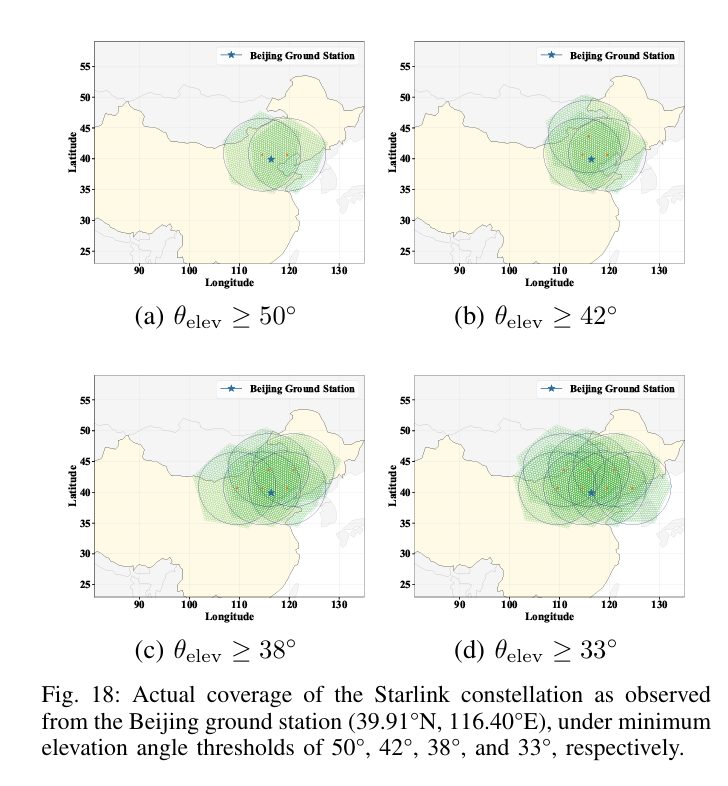

### E. 可扩展性结果

图 18 展示了从北京地面站（39.91° N，116.40° E）观测到的实际 Starlink 覆盖情况。我们将最小接收仰角分别设为 50°、42°、38° 和 33°。通过统计可见卫星数量及覆盖范围内的 H3 小区总数，得到表 III 所列的三个扩展实验场景。

图 16 和图 17 展示了三个扩展场景中的吞吐量与时延。结果表明，并非所有算法都具有良好的可扩展性。Aidos 表现出最佳的可扩展性，能够随着波束数量增加应对大规模网络。它始终保持最高吞吐量，比 MOGA-BH 高出 79.2%–123.1%，并将时延保持在 5 s 以下。相比之下，SA-BH 在波束数量较多时性能显著下降。尽管 MOGA-BH 优于 SA-BH，但总体上仍不及 Aidos。受演化步长与计算时间的限制，MOGA-BH 更适合优先考虑精度、实时性要求较低的离线规划。

### F. 计算时间

表 IV 表明，Aidos 的平均运行时间随问题规模近似线性增长，说明问题实例规模与迭代次数是决定其计算开销的主要因素。当迭代次数上限统一设为 150 时，即使在最大规模场景下，Aidos 仍可在 2 分钟内完成计算，其计算时间比 MOGA-BH 低约 54.5%。SA-BH、Greedy-BH 和 Random-BH 的运行时间均低于 3 s，即使在最大规模下仍能保持实时性，但其解的质量明显低于 Aidos。

根据收敛性分析，Aidos 的迭代次数上限可以降至 50，而不牺牲解的最优性。在此限制下，最大规模场景中的平均运行时间降至 23 s。这些结果表明，所采用的外层循环设置在解的质量与运行时间之间实现了实用的平衡。大幅增加迭代预算只会带来有限的改进，同时增加计算时间。在该场景中，最小仰角为 33°，轨道高度为 550 km 的 LEO 卫星过境时间窗口约为 300 s。因此，Aidos 可以在一个可见时间窗口内重新计算约 13 次，为在线重规划提供充足机会，并确保良好的实时性能。

### 表 IV：不同算法的平均计算时间

| 算法 | 场景 0（s） | 场景 1（s） | 场景 2（s） | 场景 3（s） |
|---|---:|---:|---:|---:|
| MOGA-BH | 67.793 | 88.560 | 128.374 | 151.451 |
| Aidos（150 次迭代） | 30.903 | 49.050 | 69.7837 | 86.140 |
| **Aidos（50 次迭代）** | **9.298** | **17.204** | **19.971** | **22.952** |

## VI. 结论

本文提出了 Aidos，一种用于计算 BHTP 的混合优化算法。该方法将业务流量感知的随机键编码与多目标元启发式搜索相结合，并进一步在自适应分布演化过程中采用滑动窗口 Beta 重采样，以提高效率与解的质量。与 MOGA-BH 和 MADRL-BH 相比，Aidos 的吞吐量分别提高了 79.2% 和 247.2%，时延降低了 99.45%。在不同小区数量下开展的可扩展性实验表明，当迭代次数上限设为 50 代时，Aidos 在包含 1,127 个小区的场景中平均运行时间为 9.3 s。该时间处于 300 s 的卫星过境时间窗口内，支持多次在线重新优化。这些结果证实，Aidos 适用于大规模 NGSO 星座中的实时 BHTP 生成。

未来工作将研究面向 LEO 巨型星座系统、具有更强可扩展性的分布式实现与多卫星协同调度架构。此外，还将扩展当前的 BH 框架，将功率这一额外维度的资源分配纳入其中。这可能提高资源分配的灵活性，但也会带来更具挑战性的高维耦合优化问题。

## 致谢

本研究获得上海市自然科学基金资助，项目编号为 25ZR1402021。